# Часть 1 Бустинг (5 баллов)

В этой части будем предсказывать зарплату data scientist-ов в зависимости  от ряда факторов с помощью градиентного бустинга.

В датасете есть следующие признаки:



* work_year: The number of years of work experience in the field of data science.

* experience_level: The level of experience, such as Junior, Senior, or Lead.

* employment_type: The type of employment, such as Full-time or Contract.

* job_title: The specific job title or role, such as Data Analyst or Data Scientist.

* salary: The salary amount for the given job.

* salary_currency: The currency in which the salary is denoted.

* salary_in_usd: The equivalent salary amount converted to US dollars (USD) for comparison purposes.

* employee_residence: The country or region where the employee resides.

* remote_ratio: The percentage of remote work offered in the job.

* company_location: The location of the company or organization.

* company_size: The company's size is categorized as Small, Medium, or Large.

In [1]:
import pandas as pd

df = pd.read_csv("ds_salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


## Задание 1 (0.5 балла) Подготовка



*   Разделите выборку на train, val, test (80%, 10%, 10%)
*   Выдерите salary_in_usd в качестве таргета
*   Найдите и удалите признак, из-за которого возможен лик в данных


In [2]:
from sklearn.model_selection import train_test_split

y = df['salary_in_usd']
X = df.drop(["salary_in_usd", 'salary'], axis=1, inplace=False)
#удаляем salary, т.к. это тот же самый таргет но в другой валюте

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=67)
X_train_train, X_train_val, y_train_train, y_train_val = train_test_split(X_train, y_train, test_size=1/9, random_state=67)


## Задание 2 (0.5 балла) Линейная модель


*   Закодируйте категориальные  признаки с помощью OneHotEncoder
*   Обучите модель линейной регрессии
*   Оцените  качество через MAPE и RMSE


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder

categorical_features = ['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size']

encoder = OneHotEncoder(drop='first', sparse_output=False, dtype=int, handle_unknown='ignore')

encoded_features = encoder.fit_transform(X_train_train[categorical_features])
encoded_col_names = encoder.get_feature_names_out(categorical_features)

X_train_train_enc, X_train_val_enc, X_test_enc = [
    pd.concat([
        df.drop(columns=categorical_features).reset_index(drop=True),
        pd.DataFrame(
            encoder.transform(df[categorical_features]),
            columns=encoder.get_feature_names_out(categorical_features)
        )
    ], axis=1)
    for df in [X_train_train, X_train_val, X_test]
]

# обучаем линейную регрессию
lr = LinearRegression()
lr.fit(X_train_train_enc, y_train_train)

y_pred = lr.predict(X_test_enc)
mape_lr = mean_absolute_percentage_error(y_test, y_pred)
rmse_lr = root_mean_squared_error(y_test, y_pred)
print(f'MAPE: {mape_lr:.4f}')
print(f'RMSE: {rmse_lr:.4f}')

MAPE: 0.3854
RMSE: 45378.0597


c:\Users\YOGA\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\YOGA\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


## Задание 3 (0.5 балла) XGboost

Начнем с библиотеки xgboost.

Обучите модель `XGBRegressor` на тех же данных, что линейную модель, подобрав оптимальные гиперпараметры (`max_depth, learning_rate, n_estimators, gamma`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [16]:
from xgboost.sklearn import XGBRegressor
import numpy as np
from sklearn.metrics import  mean_squared_error

np.random.seed(52)
params = {
    'max_depth' : np.arange(3, 11),
    'learning_rate' : np.linspace(0.01, 0.3, 10),
    'n_estimators' : np.arange(100, 501, 50),
    'gamma' : np.linspace(0, 1, 10),
}

n = 100
min_mse = float('inf')
best_params = {}
for _ in range(n):
    curr_params = {
        'max_depth': np.random.choice(params['max_depth']),
        'learning_rate': np.random.choice(params['learning_rate']),
        'n_estimators': np.random.choice(params['n_estimators']),
        'gamma': np.random.choice(params['gamma']),
    }
    xgb_reg = XGBRegressor(**curr_params, random_state=67)
    xgb_reg.fit(X_train_train_enc, y_train_train)

    y_pred = xgb_reg.predict(X_train_val_enc)
    curr_mse = mean_squared_error(y_train_val, y_pred)
    if curr_mse < min_mse:
        min_mse = curr_mse
        best_params = curr_params.copy()

print(f'Best params: {best_params}')
print(f'Validation MSE: {min_mse:.4f}')

Best params: {'max_depth': np.int64(8), 'learning_rate': np.float64(0.20333333333333334), 'n_estimators': np.int64(250), 'gamma': np.float64(0.2222222222222222)}
Validation MSE: 2324120576.0000


In [17]:
# итого обученная модель
import time

xgb_reg = XGBRegressor(**best_params, random_state=67)
start_fit = time.time()
xgb_reg.fit(X_train_train_enc, y_train_train)
end_fit = time.time()

start_pred = time.time()
y_pred = xgb_reg.predict(X_test_enc)
end_pred = time.time()
mape_xgb = mean_absolute_percentage_error(y_test, y_pred)
rmse_xgb = root_mean_squared_error(y_test, y_pred)

print(f'Fitting time: {(end_fit - start_fit):.4f}')
print(f'Prediction time: {(end_pred - start_pred):.4f}')
print()
print(f'MAPE: {mape_xgb:.4f}')
print(f'RMSE: {rmse_xgb:.4f}')

Fitting time: 0.6560
Prediction time: 0.0277

MAPE: 0.3467
RMSE: 47758.3633


## Задание 4 (1 балл) CatBoost

Теперь библиотека CatBoost.

Обучите модель `CatBoostRegressor`, подобрав оптимальные гиперпараметры (`depth, learning_rate, iterations`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [27]:
from catboost import CatBoostRegressor

np.random.seed(52)
params = {
    'depth' : np.arange(3, 11),
    'learning_rate' : np.linspace(0.01, 0.3, 10),
    'iterations' : np.arange(100, 501, 50),
}

n = 100
min_mse = float('inf')
best_params = {}
for _ in range(n):
    curr_params = {
        'depth': np.random.choice(params['depth']),
        'learning_rate': np.random.choice(params['learning_rate']),
        'iterations': np.random.choice(params['iterations']),
    }
    catboost_reg = CatBoostRegressor(**curr_params, random_seed=67, silent=True)
    catboost_reg.fit(X_train_train_enc, y_train_train)

    y_pred = catboost_reg.predict(X_train_val_enc)
    curr_mse = mean_squared_error(y_train_val, y_pred)
    if curr_mse < min_mse:
        min_mse = curr_mse
        best_params = curr_params.copy()

print(f'Best params: {best_params}')
print(f'Validation MSE: {min_mse:.4f}')

Best params: {'depth': np.int64(9), 'learning_rate': np.float64(0.23555555555555557), 'iterations': np.int64(250)}
Validation MSE: 2382979800.2151


In [28]:
catboost_reg = CatBoostRegressor(**best_params, random_seed=67, silent=True)
start_fit = time.time()
catboost_reg.fit(X_train_train_enc, y_train_train)
end_fit = time.time()

start_pred = time.time()
y_pred = catboost_reg.predict(X_test_enc)
end_pred = time.time()
mape_catboost = mean_absolute_percentage_error(y_test, y_pred)
rmse_catboost = root_mean_squared_error(y_test, y_pred)

print(f'Fitting time: {(end_fit - start_fit):.4f}')
print(f'Prediction time: {(end_pred - start_pred):.4f}')
print()
print(f'MAPE: {mape_catboost:.4f}')
print(f'RMSE: {rmse_catboost:.4f}')

Fitting time: 1.8198
Prediction time: 0.0105

MAPE: 0.3387
RMSE: 45886.3677


Для применения catboost моделей не обязательно сначала кодировать категориальные признаки, модель может кодировать их сама. Обучите catboost с подбором оптимальных гиперпараметров снова, используя pool для передачи данных в модель с указанием какие признаки категориальные, а какие нет с помощью параметра cat_features. Оцените качество и время. Стало ли лучше?

In [25]:
from catboost import Pool

train_pool = Pool(data=X_train_train, label=y_train_train, cat_features=categorical_features)
val_pool = Pool(data=X_train_val, label=y_train_val, cat_features=categorical_features)
test_pool = Pool(data=X_test, cat_features=categorical_features)

#снова подберём параметры
np.random.seed(52)
params = {
    'depth' : np.arange(3, 11),
    'learning_rate' : np.linspace(0.01, 0.3, 10),
    'iterations' : np.arange(100, 501, 50),
}

n = 50
min_mse = float('inf')
best_params = {}
for _ in range(n):
    curr_params = {
        'depth': np.random.choice(params['depth']),
        'learning_rate': np.random.choice(params['learning_rate']),
        'iterations': np.random.choice(params['iterations']),
    }
    catboost_pool_reg = CatBoostRegressor(**curr_params, random_seed=67, silent=True,  early_stopping_rounds=50)
    catboost_pool_reg.fit(train_pool)

    y_pred = catboost_pool_reg.predict(val_pool)
    curr_mse = mean_squared_error(y_train_val, y_pred)
    if curr_mse < min_mse:
        min_mse = curr_mse
        best_params = curr_params.copy()

print(f'Best params: {best_params}')
print(f'Validation MSE: {min_mse:.4f}')

Best params: {'depth': np.int64(4), 'learning_rate': np.float64(0.20333333333333334), 'iterations': np.int64(400)}
Validation MSE: 2586491458.8284


In [26]:
catboost_pool_reg = CatBoostRegressor(**best_params, random_seed=67, silent=True)
start_fit = time.time()
catboost_pool_reg.fit(train_pool)
end_fit = time.time()

start_pred = time.time()
y_pred = catboost_pool_reg.predict(test_pool)
end_pred = time.time()
mape_catboost_pool = mean_absolute_percentage_error(y_test, y_pred)
rmse_catboost_pool = root_mean_squared_error(y_test, y_pred)

print(f'Fitting time: {(end_fit - start_fit):.4f}')
print(f'Prediction time: {(end_pred - start_pred):.4f}')
print()
print(f'MAPE: {mape_catboost_pool:.4f}')
print(f'RMSE: {rmse_catboost_pool:.4f}')

Fitting time: 14.9110
Prediction time: 0.0028

MAPE: 0.3749
RMSE: 44552.6390


**Ответ:** Сравним на табличке

Model | CatBoost | CatBoost + Pool
------|----------|----------------
Fitting time | 1.8198 | 14.9110
Prediction time | 0.0105 | 0.0028
MAPE | 0.3387 | 0.3749
RMSE | 45886.3677 | 44552.6390

Время обучения для версии с pool вышло в 8 раз дольше, но предсказание получилось почти в 4 раза быстрее. При этом качество практически одинаковое (без pool даже лучше на mape)

Если собрать все плюсы и минусы, то как будто лучше не стало(

## Задание 5 (0.5 балла) LightGBM

И наконец библиотека LightGBM - используйте `LGBMRegressor`, снова подберите гиперпараметры, оцените качество и скорость.


In [30]:
from lightgbm import LGBMRegressor

np.random.seed(52)
params = {
    'max_depth' : np.arange(3, 11),
    'learning_rate' : np.linspace(0.01, 0.3, 10),
    'n_estimators' : np.arange(100, 501, 50),
}

n = 100
min_mse = float('inf')
best_params = {}
for _ in range(n):
    curr_params = {
        'max_depth': np.random.choice(params['max_depth']),
        'learning_rate': np.random.choice(params['learning_rate']),
        'n_estimators': np.random.choice(params['n_estimators']),
    }
    lgbm_reg = LGBMRegressor(**curr_params, random_state=67, verbose=-1 )
    lgbm_reg.fit(X_train_train_enc, y_train_train)

    y_pred = lgbm_reg.predict(X_train_val_enc)
    curr_mse = mean_squared_error(y_train_val, y_pred)
    if curr_mse < min_mse:
        min_mse = curr_mse
        best_params = curr_params.copy()

print(f'Best params: {best_params}')
print(f'Validation MSE: {min_mse:.4f}')

Best params: {'max_depth': np.int64(6), 'learning_rate': np.float64(0.1711111111111111), 'n_estimators': np.int64(150)}
Validation MSE: 2525676861.8344


In [32]:
# -- YOUR CODE HERE --
lgbm_reg = LGBMRegressor(**best_params, random_state=67, verbose=-1 )
start_fit = time.time()
lgbm_reg.fit(X_train_train_enc, y_train_train)
end_fit = time.time()

start_pred = time.time()
y_pred = lgbm_reg.predict(X_test_enc)
end_pred = time.time()
mape_catboost_pool = mean_absolute_percentage_error(y_test, y_pred)
rmse_catboost_pool = root_mean_squared_error(y_test, y_pred)

print(f'Fitting time: {(end_fit - start_fit):.4f}')
print(f'Prediction time: {(end_pred - start_pred):.4f}')
print()
print(f'MAPE: {mape_catboost_pool:.4f}')
print(f'RMSE: {rmse_catboost_pool:.4f}')

Fitting time: 0.1056
Prediction time: 0.0058

MAPE: 0.3310
RMSE: 44847.1510


## Задание 6 (2 балла) Сравнение и выводы

Сравните модели бустинга и сделайте про них выводы, какая из моделей показала лучший/худший результат по качеству, скорости обучения и скорости предсказания? Как отличаются гиперпараметры для разных моделей?

**Ответ:** Сравним на табличках

1. Время работы и качество предсказаний

Model | XGboost | CatBoost | CatBoost + Pool | LightGBM
------|---------|----------|-----------------|---------
Fitting time | 0.6560 | 1.8198 | 14.9110 | 0.1056
Prediction time | 0.0277 | 0.0105 | 0.0028 | 0.0058
MAPE | 0.3467 | 0.3387 | 0.3749 | 0.3310
RMSE | 47758.3633 | 45886.3677 | 44552.6390 | 44847.1510

Качество предсказаний:
* Лучший результат показал LightGBM - минимальный MAPE и второй по минимальности RMSE
* CatBoost + Pool - минимальный RMSE, но худший MAPE
* CatBoost где-то посередине по всем метрикам
* XGboost - худший по RMSE, второй по худшести MAPE

Итого: если критичны большие отклонения, то лучшим будет CatBoost + Pool, а если относительная точность, то LightGBM

Скорость обучения:
* LightGBM обучается на порядок быстрее всех из-за роста дерева по листьям, а не по уровням, а также меньшего n_estimators
* XGBoost тоже довольно быстрый
* CatBoost заметно медленнее (из-за симметричного построения деревьев)
* CatBoost + Pool - самый медленный. Скорее всего так происходит из-за построения pool + бОльшего числа деревьев (400)

Скорость предсказания:
* CatBoost + Pool - самый быстрый из-за pool + меньшей глубины деревьев (4)
* LightGBM и CatBoost также довольно быстрые
* XGBoost - самый медленный, вероятно из-за большой глубины (8)

2. Параметры

Model | XGboost | CatBoost | CatBoost + Pool | LightGBM
------|---------|----------|-----------------|---------
max_depth | 8 | 9 | 4 | 6
learning_rate | 0.203 | 0.236 | 0.203 | 0.171
n_estimators | 250 | 250 | 400 | 150
gamma | 0.222 | - | - | -

Отличия:
* max_depth: CatBoost+Pool использует самые неглубокие деревья, но компенсирует это бОльшим числом деревьев. XGBoost и CatBoost - глубокие деревья при меньшем n_estimators (250)
* learning_rate: у всех моделей примерно в одном диапазоне (около 0.2)
* n_estimators: LightGBM требует меньше деревьев (150) для достижения лучшего качества (из-за построения по листьям)


### Итог

* LightGBM - лучшая модель в целом: лучшее качество по MAPE, на порядок быстрее обучается, быстрые предсказания
* CatBoost + Pool даёт лучший RMSE и самые быстрые предсказания, но очень долго обучается - подходит, если модель обучается редко, но используется часто
* CatBoost - компромиссный вариант, средний и по метрикам, и по скорости обучения/предсказания
* XGBoost - худший по соотношению качество/скорость предсказания, хотя обучается быстро


# Часть 2 Кластеризация (5 баллов)

Будем работать с данными о том, каких исполнителей слушают пользователи музыкального сервиса.

Каждая строка таблицы - информация об одном пользователе. Каждый столбец - это исполнитель (The Beatles, Radiohead, etc.)

Для каждой пары (пользователь, исполнитель) в таблице стоит число - доля прослушивания этого исполнителя этим пользователем.


In [117]:
import pandas as pd
ratings = pd.read_excel("https://github.com/evgpat/edu_stepik_rec_sys/blob/main/datasets/sample_matrix.xlsx?raw=true", engine='openpyxl')
ratings.head()

,user,the beatles,radiohead,deathcab for cutie,coldplay,modest mouse,sufjan stevens,dylan. bob,red hot clili peppers,pink fluid,...,municipal waste,townes van zandt,curtis mayfield,jewel,lamb,michal w. smith,群星,agalloch,meshuggah,yellowcard
0,0,NaN,0.020417,NaN,NaN,NaN,NaN,NaN,0.030496,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,0.184962,0.024561,NaN,NaN,0.136341,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,0.028635,NaN,NaN,NaN,0.024559,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0.043529,0.086281,0.034590,0.016712,0.015935,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Будем строить кластеризацию исполнителей: если двух исполнителей слушало много людей примерно одинаковую долю своего времени (то есть векторы близки в пространстве), то, возможно исполнители похожи. Эта информация может быть полезна при построении рекомендательных систем.

## Задание 1 (0.5 балла) Подготовка

Транспонируем матрицу ratings, чтобы по строкам стояли исполнители.

In [118]:
ratings = ratings.T
ratings.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
user,0.000000,1.000000,2.000000,3.0,4.000000,5.000000,6.0,7.0,8.000000,9.000000,...,4990.000000,4991.0,4992.000000,4993.000000,4994.000000,4995.000000,4996.0,4997.000000,4998.0,4999.000000
the beatles,NaN,NaN,NaN,NaN,0.043529,NaN,NaN,NaN,0.093398,0.017621,...,NaN,NaN,0.121169,0.038168,0.007939,0.017884,NaN,0.076923,NaN,NaN
radiohead,0.020417,0.184962,NaN,NaN,0.086281,0.006322,NaN,NaN,NaN,0.019156,...,0.017735,NaN,NaN,NaN,0.011187,NaN,NaN,NaN,NaN,NaN
deathcab for cutie,NaN,0.024561,0.028635,NaN,0.034590,NaN,NaN,NaN,NaN,0.013349,...,0.121344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027893
coldplay,NaN,NaN,NaN,NaN,0.016712,NaN,NaN,NaN,NaN,NaN,...,0.217175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Выкиньте строку под названием `user`.

In [119]:
ratings = ratings.drop(['user'])
ratings.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
the beatles,NaN,NaN,NaN,NaN,0.043529,NaN,NaN,NaN,0.093398,0.017621,...,NaN,NaN,0.121169,0.038168,0.007939,0.017884,NaN,0.076923,NaN,NaN
radiohead,0.020417,0.184962,NaN,NaN,0.086281,0.006322,NaN,NaN,NaN,0.019156,...,0.017735,NaN,NaN,NaN,0.011187,NaN,NaN,NaN,NaN,NaN
deathcab for cutie,NaN,0.024561,0.028635,NaN,0.034590,NaN,NaN,NaN,NaN,0.013349,...,0.121344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027893
coldplay,NaN,NaN,NaN,NaN,0.016712,NaN,NaN,NaN,NaN,NaN,...,0.217175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
modest mouse,NaN,NaN,NaN,NaN,0.015935,NaN,NaN,NaN,NaN,0.030437,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


В таблице много пропусков, так как пользователи слушают не всех-всех исполнителей, чья музыка представлена в сервисе, а некоторое подмножество (обычно около 30 исполнителей)


Доля исполнителя в музыке, прослушанной  пользователем, равна 0, если пользователь никогда не слушал музыку данного музыканта, поэтому заполните пропуски нулями.



In [120]:
ratings = ratings.fillna(0)
ratings.sample()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
paul mcmartney,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.002653,0.0,0.0


## Задание 2 (0.5 балла) Первая кластеризация

Примените KMeans с 5ю кластерами, сохраните полученные лейблы

In [121]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(ratings)
ratings['cluster'] = labels

Выведите размеры кластеров. Полезной ли получилась кластеризация? Почему KMeans может выдать такой результат?

In [122]:
cluster_sizes = ratings['cluster'].value_counts()
print(cluster_sizes)

cluster
3    882
0    115
4      1
2      1
1      1
Name: count, dtype: int64


**Ответ:** Кластеризация получилась не очень полезной, т.к. вышло много кластеров с 1 объектом и один очень большой кластер, куда попали почти все объекты. Такое могло случиться потому что:
1. В таблице слишком много нулей - практически все непопулярные исполнители (а таких большинство) попали в один кластер
2. Мало кластеров, kmeans не смог хорошо разделить всего на 5
3. Данные не были нормализованы

## Задание 3 (0.5 балла) Объяснение результатов

При кластеризации получилось $\geq 1$ кластера размера 1. Выведите исполнителей, которые составляют такие кластеры. Среди них должна быть группа The Beatles.

In [123]:
# -- YOUR CODE HERE --
singleton_clusters = cluster_sizes[cluster_sizes == 1].index
singletons = ratings[ratings['cluster'].isin(singleton_clusters)]
for i in singletons.index.tolist():
    print(i)

the beatles
niИ
日dir en grey


Изучите данные, почему именно The Beatles выделяется?

Подсказка: посмотрите на долю пользователей, которые слушают каждого исполнителя, среднюю долю прослушивания.

In [124]:
stats = pd.DataFrame({
    'listeners_fraction': (ratings.drop(columns=['cluster']) > 0).mean(axis=1),
    'mean_fraction': ratings.drop(columns=['cluster']).apply(
        lambda row: row[row > 0].mean(), axis=1
    )
})

print('Top-10 listeners_fraction')
print(stats.nlargest(10, 'listeners_fraction'))


Top-10 listeners_fraction
                       listeners_fraction  mean_fraction
the beatles                        0.3342       0.054964
radiohead                          0.2778       0.042661
deathcab for cutie                 0.1862       0.035141
coldplay                           0.1682       0.035852
modest mouse                       0.1628       0.036095
sufjan stevens                     0.1292       0.038460
dylan. bob                         0.1262       0.039323
red hot clili peppers              0.1258       0.031752
pink fluid                         0.1256       0.039085
kanye west                         0.1250       0.037128


**Ответ:** Доля пользователей, которые слушают the beatles почти вдвое больше чем для других исполнителей (кроме radiohead). Из-за того, что они намного популярнее остальных исполнителей, они и выделились в отдельный кластер

## Задание 4 (0.5 балла) Улучшение кластеризации

Попытаемся избавиться от этой проблемы: нормализуйте данные при помощи `normalize`.

In [125]:
from sklearn.preprocessing import normalize

ratings = ratings.drop(columns=['cluster'])
ratings_normalized = pd.DataFrame(
    data=normalize(ratings), 
    index=ratings.index,
    columns=ratings.columns
)

ratings_normalized.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
the beatles,0.000000,0.000000,0.000000,0.0,0.012054,0.000000,0.0,0.0,0.025864,0.004880,...,0.000000,0.0,0.033554,0.010569,0.002199,0.004952,0.0,0.021302,0.0,0.000000
radiohead,0.009348,0.084688,0.000000,0.0,0.039505,0.002894,0.0,0.0,0.000000,0.008771,...,0.008120,0.0,0.000000,0.000000,0.005122,0.000000,0.0,0.000000,0.0,0.000000
deathcab for cutie,0.000000,0.017278,0.020144,0.0,0.024333,0.000000,0.0,0.0,0.000000,0.009391,...,0.085361,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.019622
coldplay,0.000000,0.000000,0.000000,0.0,0.011129,0.000000,0.0,0.0,0.000000,0.000000,...,0.144628,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
modest mouse,0.000000,0.000000,0.000000,0.0,0.010260,0.000000,0.0,0.0,0.000000,0.019597,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000


Примените KMeans с 5ю кластерами на преобразованной матрице, посмотрите на их размеры. Стало ли лучше? Может ли кластеризация быть полезной теперь?

In [126]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(ratings_normalized)
ratings_normalized['cluster'] = labels

cluster_sizes = ratings_normalized['cluster'].value_counts()
cluster_sizes

cluster
4    486
1    162
3    140
2    133
0     79
Name: count, dtype: int64

**Ответ** Получился 1 большой и 1 маленький кластер + оставшиеся объекты распределились по кластерам примерно равномерно. Стало сильно лучше, такую кластеризацию уже можно считать полезной

## Задание 5 (1 балл) Центроиды

Выведите для каждого кластера названия топ-10 исполнителей, ближайших к центроиду по косинусной мере. Проинтерпретируйте результат. Что можно сказать о смысле кластеров?

In [127]:
from scipy.spatial.distance import cosine


centroids = kmeans.cluster_centers_

for i in range(kmeans.n_clusters):
    mask = labels == i
    artists = ratings_normalized.index[mask]
    dists = np.array([cosine(row, centroids[i]) for row in ratings_normalized[mask].drop(columns=['cluster']).values])
    
    top10 = np.argpartition(dists, 10)[:10]
    top10 = top10[np.argsort(dists[top10])]
    
    print(f"Cluster {i}:")
    for i, idx in enumerate(top10, 1):
        print(f"    {i}. {artists[idx]}")
    print()

Cluster 0:
    1. nas
    2. jay-z
    3. kanye west
    4. lupe the gorilla
    5. a tribe called quest
    6. the roots featuring d'angelo
    7. gangstarr
    8. little brother
    9. lil' wayne
    10. murs and 9th wonder

Cluster 1:
    1. fall out boy
    2. the all-americian rejects
    3. paramore
    4. kelly clarkson
    5. john mayer
    6. the fray
    7. maroon5
    8. dashboard confesssional
    9. somethings corporate
    10. coldplay

Cluster 2:
    1. brand new
    2. blink-182
    3. alkaline trio
    4. against me!
    5. underoath
    6. descendents
    7. new found glory
    8. less than jake
    9. thrice
    10. chiodos

Cluster 3:
    1. the beatles
    2. the rolling stones
    3. dylan. bob
    4. who
    5. led zeppelin.
    6. miles davis.
    7. simon and garfunkel
    8. young, neil
    9. pink fluid
    10. velvet underground

Cluster 4:
    1. radiohead
    2. the arcade fire
    3. the shins
    4. sufjan stevens
    5. belle and sebastian
    6. broken

**Ответ:** В каждом кластере получилось собрать артистов примерно одного жанра (рэп/хип-хоп, поп-рок, панк (наверное), классический и альтернативный рок). То есть мы смогли:
1. С помощью кластеризации по пользователям разделить исполнителей по жанрам (т.к. если у пользователя есть любимый жанр, то он, в основном, слушает исполнителей именно в этом жанре)
2. С помощью центроидов выделить самых ярких/известных представителей каждого жанра

## Задание 6 (1 балл) Визуализация

Хотелось бы как-то визуализировать полученную кластеризацию. Постройте точечные графики `plt.scatter` для нескольких пар признаков исполнителей, покрасив точки в цвета кластеров. Почему визуализации получились такими? Хорошо ли они отражают разделение на кластеры? Почему?

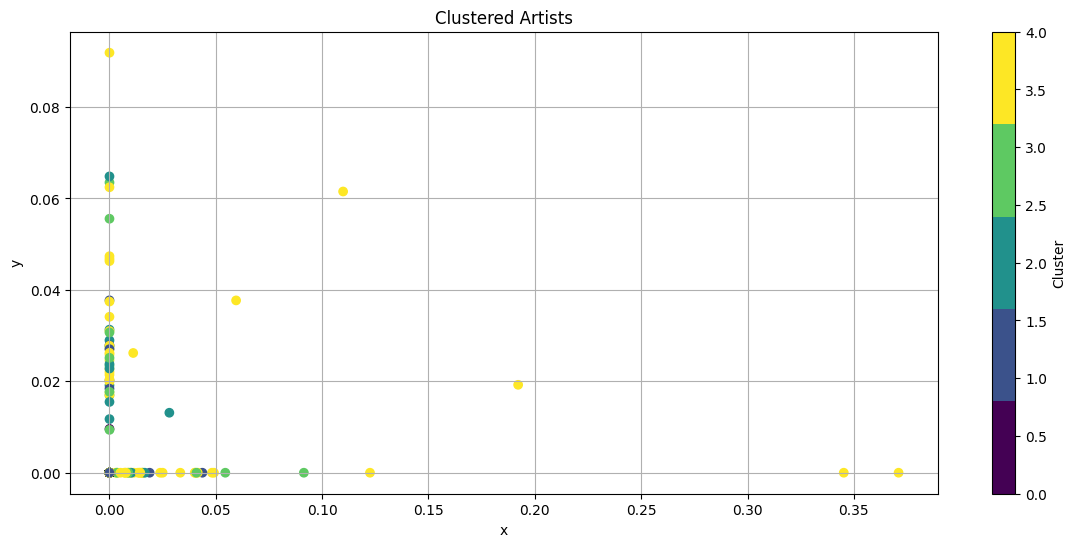

In [128]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.scatter(
    x=ratings_normalized[5],
    y=ratings_normalized[2],
    c=labels,
    cmap=plt.get_cmap('viridis', 5),
)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Clustered Artists')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

**Ответ:** У нас много данных, но осей всего две - получился практически нечитабельный график

Для визуализации данных высокой размерности существует метод t-SNE (стохастическое вложение соседей с t-распределением). Данный метод является нелинейным методом снижения размерности: каждый объект высокой размерности будет моделироваться объектов более низкой (например, 2) размерности таким образом, чтобы похожие объекты моделировались близкими, непохожие - далекими с большой вероятностью.

Примените `TSNE` из библиотеки `sklearn` и визуализируйте полученные объекты, покрасив их в цвета их кластеров

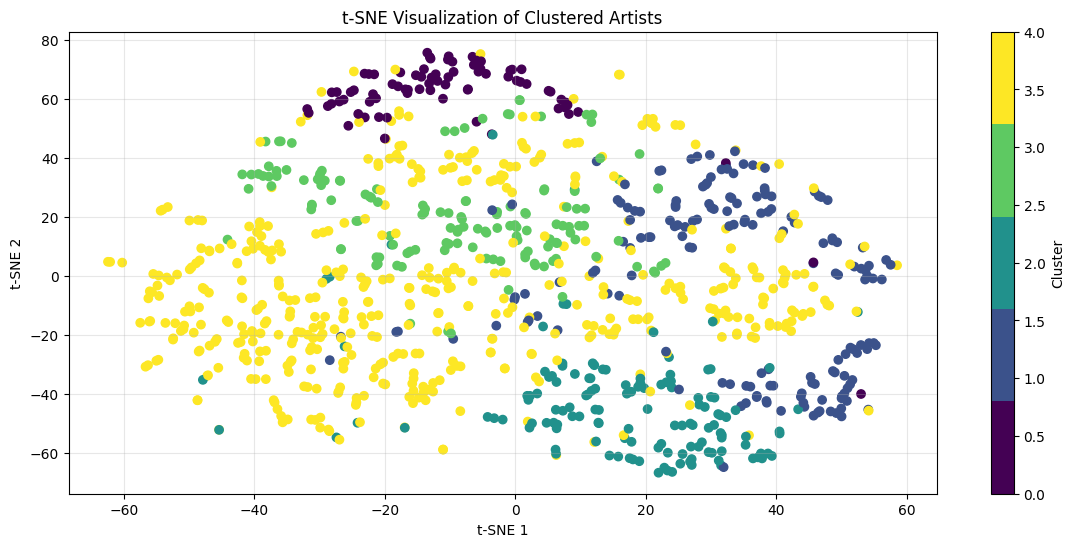

In [129]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=67, perplexity=10)
tsne_result = tsne.fit_transform(ratings_normalized.drop(columns=['cluster']).values)

tsne_df = pd.DataFrame(tsne_result, columns=['TSNE_1', 'TSNE_2'])
tsne_df['cluster'] = ratings_normalized['cluster'].values

plt.figure(figsize=(14, 6))
scatter = plt.scatter(
    tsne_df['TSNE_1'],
    tsne_df['TSNE_2'],
    c=tsne_df['cluster'],
    cmap=plt.get_cmap('viridis', 5),
)
plt.title('t-SNE Visualization of Clustered Artists')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

## Задание 7 (1 балл) Подбор гиперпараметров

Подберите оптимальное количество кластеров (максимум 100 кластеров) с использованием индекса Силуэта. Зафиксируйте `random_state=42`

In [ ]:
from sklearn.metrics import silhouette_score
# работает очень долго - 37 минут....
scores = {}
ratings_normalized = ratings_normalized.drop(columns=['cluster'])
for k in range(2, 101):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(ratings_normalized.values)
    score = silhouette_score(ratings_normalized.values, labels)
    scores[k] = score

best_k = max(scores, key=scores.get)
print(f'Best number of clusters: {best_k}')

Best number of clusters: 98


Выведите исполнителей, ближайших с центроидам (аналогично заданию 5). Как соотносятся результаты? Остался ли смысл кластеров прежним? Расскажите про смысл 1-2 интересных кластеров, если он изменился и кластеров слишком много, чтобы рассказать про все.

In [135]:
ratings_normalized = ratings_normalized.drop(columns=['cluster'])

kmeans = KMeans(n_clusters=best_k, random_state=42)
labels = kmeans.fit_predict(ratings_normalized)
ratings_normalized['cluster'] = labels

cluster_sizes = ratings_normalized['cluster'].value_counts()

centroids = kmeans.cluster_centers_

for i in range(kmeans.n_clusters):
    mask = labels == i
    artists = ratings_normalized.index[mask]
    dists = np.array([cosine(row, centroids[i]) for row in ratings_normalized[mask].drop(columns=['cluster']).values])

    n_top = min(5, len(dists))
    top5 = np.argpartition(dists, n_top-1)[:n_top]
    top5 = top5[np.argsort(dists[top5])]
    
    print(f"Cluster {i}:")
    for i, idx in enumerate(top5, 1):
        print(f"    {i}. {artists[idx]}")
    print()

Cluster 0:
    1. dr. dre
    2. the faint
    3. violent femmes
    4. margot and the nuclear so and sos
    5. owen

Cluster 1:
    1. john mayer
    2. matt nathanson
    3. gavin degraw
    4. jason mraz
    5. ray lamontagne

Cluster 2:
    1. white stripes
    2. beck
    3. the raconteurs
    4. spoon
    5. the pixies

Cluster 3:
    1. fugazi
    2. jawbreaker
    3. sleater-kinney
    4. les savy fav
    5. capn jazz

Cluster 4:
    1. ryan adams
    2. band of horses
    3. ryan adams and the cardinals
    4. rogue wave
    5. my morning jacket

Cluster 5:
    1. dj shadow
    2. rjd2
    3. amon tobin
    4. jedi mind tricks
    5. el-p

Cluster 6:
    1. system of a down
    2. koЯn
    3. mudvayne
    4. limpt bizkit
    5. disturbed

Cluster 7:
    1. somethings corporate
    2. the rocket summer
    3. jack’s mannequin
    4. cartel
    5. the format

Cluster 8:
    1. chiodos
    2. underoath
    3. scary kids scaring kids
    4. saosin
    5. norma jean

Cluster 9:
  

**Ответ:** Смысл классов остался тем же, но деление на жанры стало более точным. Из интересных кластеров: 73 - классическая музыка (ルートヴィヒ・ヴァン・ベートーヴェン - это Бетховен....), 38 - женская поп музыка (и там даже есть tatu)


Сделайте t-SNE визуализацию полученной кластеризации.

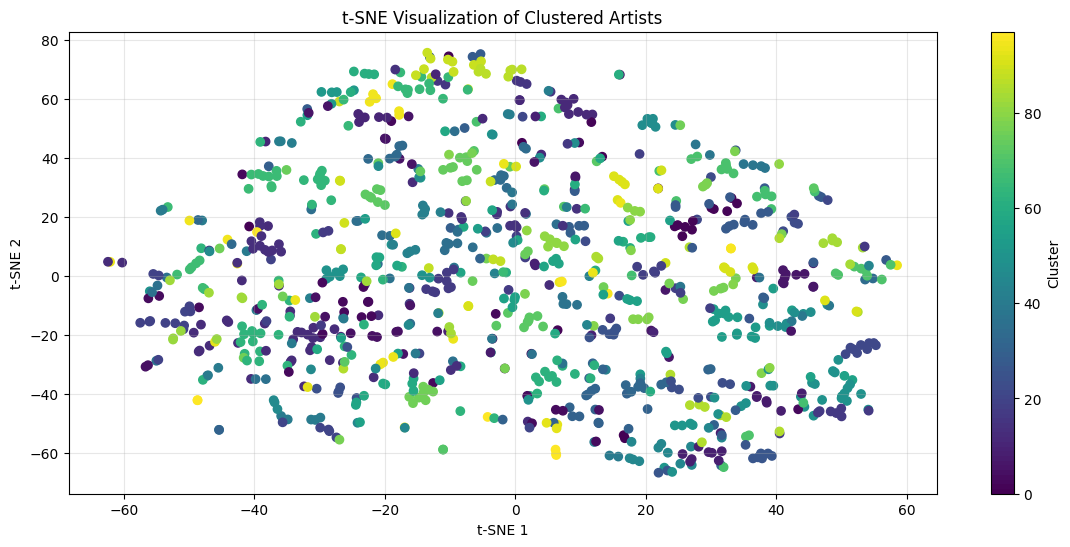

In [136]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=67, perplexity=10)
tsne_result = tsne.fit_transform(ratings_normalized.drop(columns=['cluster']).values)

tsne_df = pd.DataFrame(tsne_result, columns=['TSNE_1', 'TSNE_2'])
tsne_df['cluster'] = ratings_normalized['cluster'].values

plt.figure(figsize=(14, 6))
scatter = plt.scatter(
    tsne_df['TSNE_1'],
    tsne_df['TSNE_2'],
    c=tsne_df['cluster'],
    cmap=plt.get_cmap('viridis', kmeans.n_clusters),
)
plt.title('t-SNE Visualization of Clustered Artists')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

Если кластеров получилось слишком много и визуально цвета плохо отличаются, покрасьте только какой-нибудь интересный кластер из задания выше (`c = (labels == i)`). Хорошо ли этот кластер отражается в визуализации?

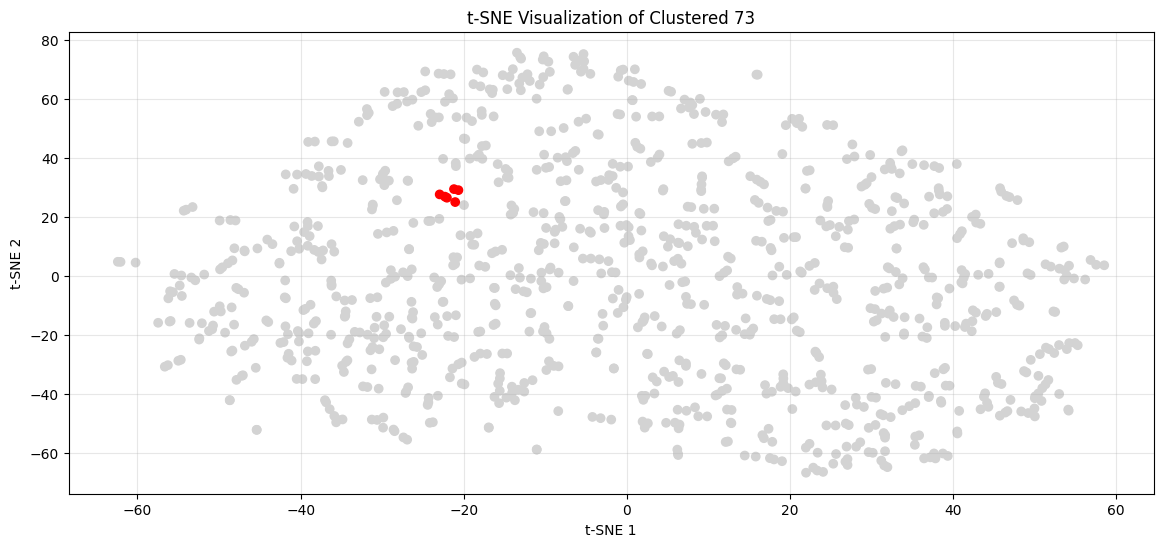

In [139]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=67, perplexity=10)
tsne_result = tsne.fit_transform(ratings_normalized.drop(columns=['cluster']).values)

tsne_df = pd.DataFrame(tsne_result, columns=['TSNE_1', 'TSNE_2'])
tsne_df['cluster'] = ratings_normalized['cluster'].values

colors = np.where(tsne_df['cluster'] == 73, 'red', 'lightgray')

plt.figure(figsize=(14, 6))
scatter = plt.scatter(
    tsne_df['TSNE_1'],
    tsne_df['TSNE_2'],
    c=colors
)
plt.title('t-SNE Visualization of Clustered 73')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.3)
plt.show()

**Ответ:** Кластер 73 с классической музыкой действительно выделился. Артистов там не много, но все они расположены рядом